In [62]:
%matplotlib inline

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import math
import matplotlib.dates as mdates
import pickle
import os

from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

In [64]:
df = pd.read_csv('main_data.csv')
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3043746 entries, 0 to 3043745
Data columns (total 2 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Time (UTC)  str    
 1   prs(m)      float64
dtypes: float64(1), str(1)
memory usage: 46.4 MB


,prs(m)
count,3.029938e+06
mean,1.396747e+00
std,4.506701e-01
min,-9.060000e-01
25%,1.123000e+00
50%,1.340000e+00
75%,1.608000e+00
max,8.152700e+01


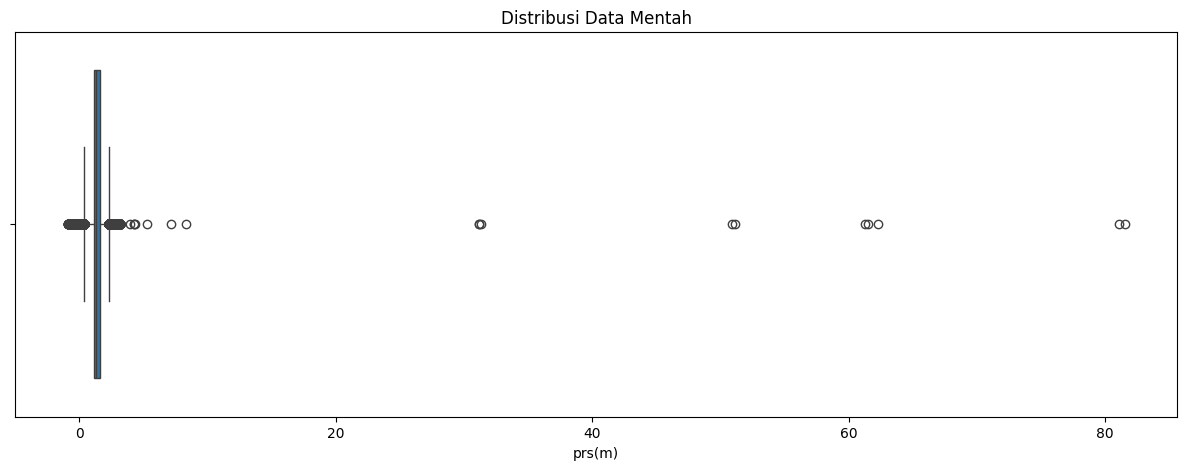

In [65]:
plt.figure(figsize=(15, 5))
sns.boxplot(x=df['prs(m)'])
plt.title('Distribusi Data Mentah')
plt.show()

In [66]:
df['Time (UTC)'] = pd.to_datetime(df['Time (UTC)'])
df.set_index('Time (UTC)', inplace=True)

display(df.head())
display(df.iloc[1500008:1500013])
display(df.tail())

,prs(m)
Time (UTC),
2020-01-01 00:01:00,0.621
2020-01-01 00:02:00,0.536
2020-01-01 00:03:00,0.688
2020-01-01 00:04:00,0.693
2020-01-01 00:05:00,0.633


,prs(m)
Time (UTC),
2023-01-17 20:15:00,1.451
2023-01-17 20:16:00,1.450
2023-01-17 20:17:00,1.456
2023-01-17 20:18:00,1.454
2023-01-17 20:19:00,1.456


,prs(m)
Time (UTC),
2025-12-31 23:56:00,2.014
2025-12-31 23:57:00,1.976
2025-12-31 23:58:00,1.972
2025-12-31 23:59:00,2.079
2026-01-01 00:00:00,1.960


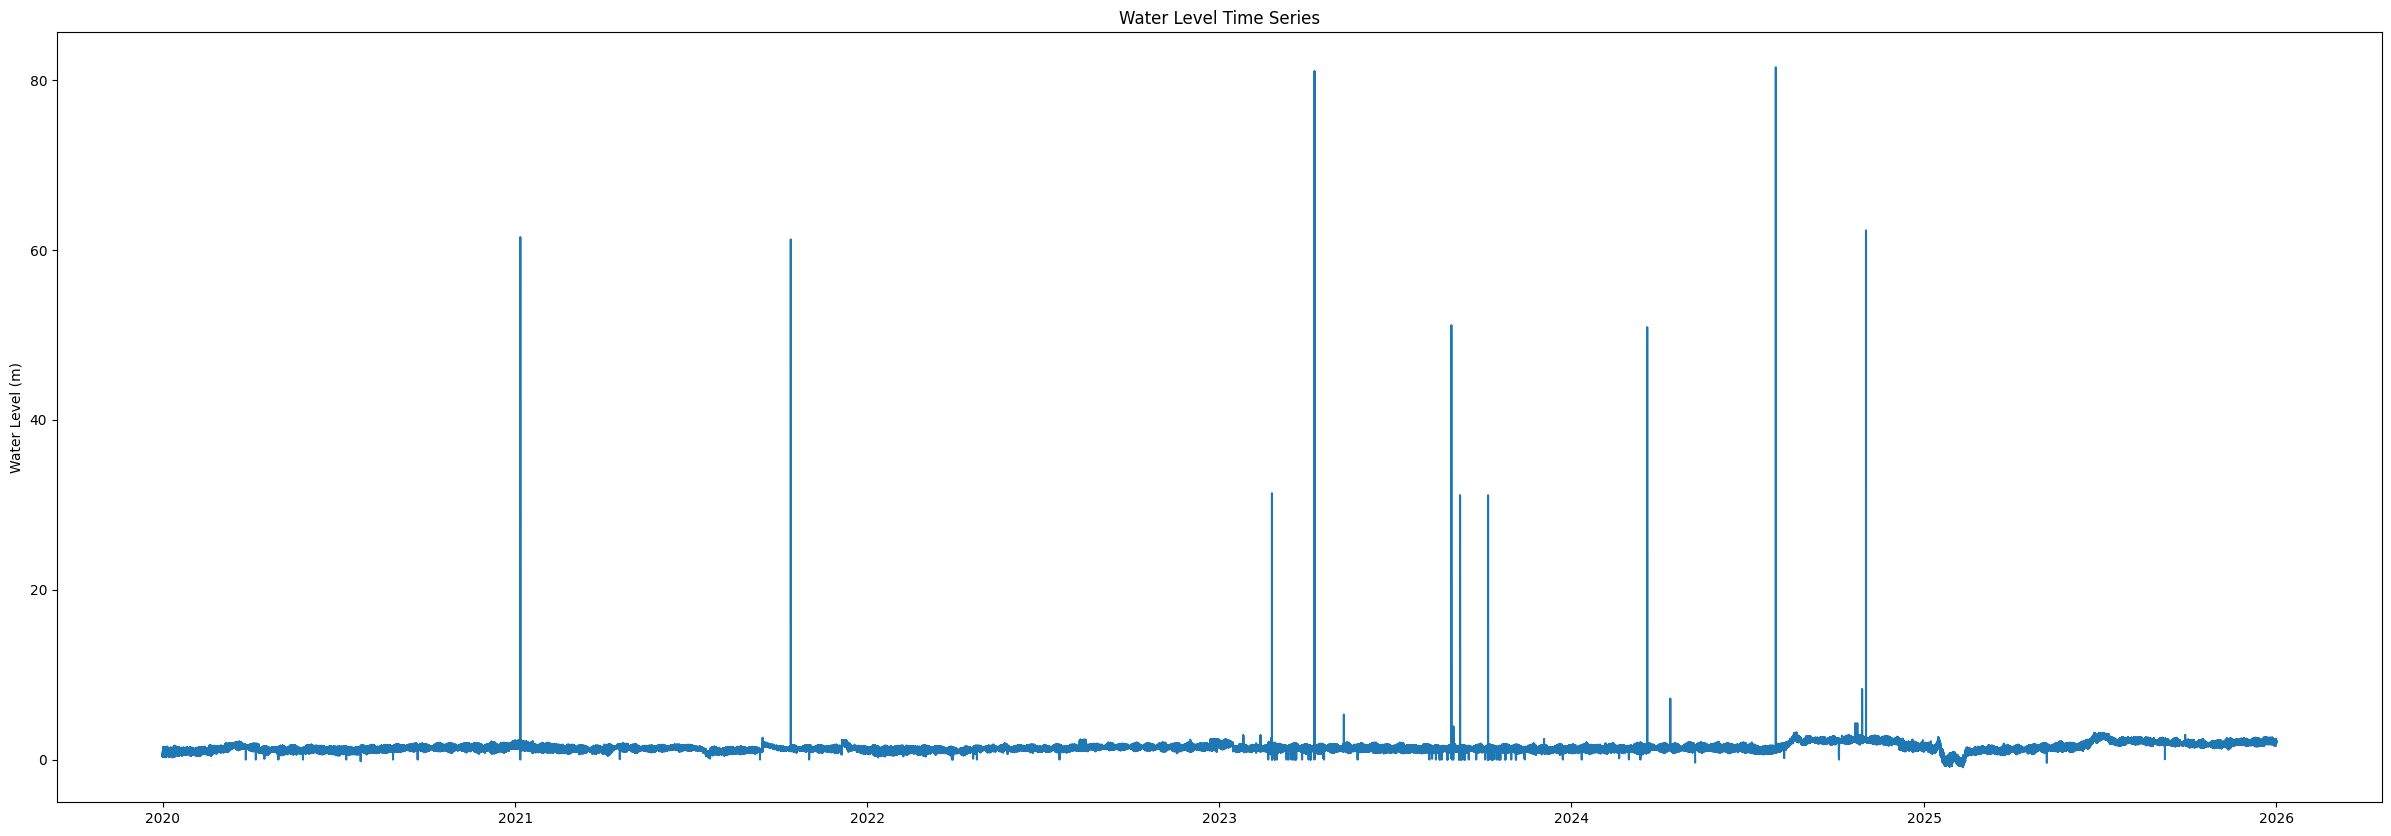

In [67]:
plt.figure(figsize=(30,10))
plt.plot(df['prs(m)'])
plt.title("Water Level Time Series")
plt.ylabel("Water Level (m)")
plt.show()

In [78]:
print("Total entries:", len(df))
print("Missing value:", df['prs(m)'].isna().sum())

Q1 = df['prs(m)'].quantile(0.25)
Q3 = df['prs(m)'].quantile(0.75)
IQR = Q3 - Q1
bb = Q1 - 1.5 * IQR
ba = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Batas Bawah:", bb)
print("Batas Atas:", ba)

nilai_missing = df['prs(m)'].isna()
nilai_outlier = (df['prs(m)'] < bb) | (df['prs(m)'] > ba)
print("Jumlah outlier:", nilai_outlier.sum())

# Tampilkan juga ringkasan baris missing dan outlier secara langsung
display(df[nilai_missing].head(6))
display(df[nilai_outlier].head(6))

Total entries: 8769
Missing value: 40
Q1: 1.352
Q3: 1.792
IQR: 0.43999999999999995
Batas Bawah: 0.6920000000000002
Batas Atas: 2.452
Jumlah outlier: 82


,prs(m)
Time (UTC),
2020-02-29 06:00:00,NaN
2020-02-29 12:00:00,NaN
2020-02-29 18:00:00,NaN
2022-05-26 12:00:00,NaN
2022-06-07 18:00:00,NaN
2022-06-17 12:00:00,NaN


,prs(m)
Time (UTC),
2021-07-19 12:00:00,0.667000
2021-07-21 06:00:00,0.671000
2021-07-21 12:00:00,0.503000
2025-01-20 00:00:00,0.409624
2025-01-21 00:00:00,0.401877
2025-01-21 06:00:00,0.405046


Sisa missing: 0
Sisa outlier: 0
Duplikasi index: 0


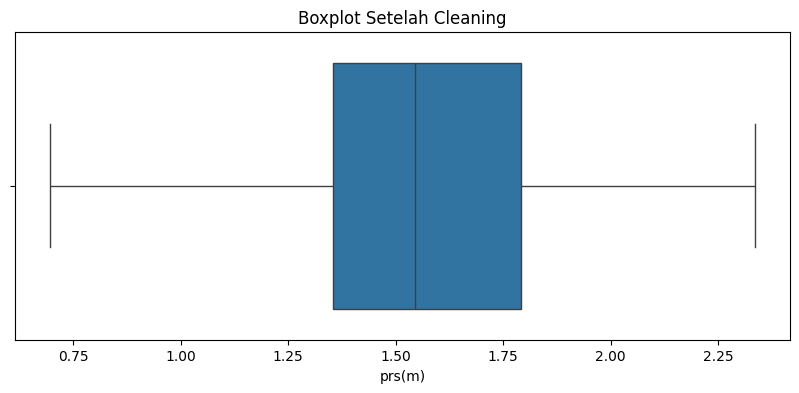

In [79]:
df = df[~df.index.duplicated(keep='first')]

df.loc[(df['prs(m)'] < bb) | (df['prs(m)'] > ba), 'prs(m)'] = np.nan

df['prs(m)'] = df['prs(m)'].interpolate(method='time')
df['prs(m)'] = df['prs(m)'].bfill().ffill()

df = df.resample('6h').max()

print("Sisa missing:", df['prs(m)'].isnull().sum())
print("Sisa outlier:", ((df['prs(m)'] < bb) | (df['prs(m)'] > ba)).sum())
print("Duplikasi index:", df.index.duplicated().sum())

plt.figure(figsize=(10,4))
sns.boxplot(x=df['prs(m)'])
plt.title("Boxplot Setelah Cleaning")
plt.show()


In [80]:
df.to_csv('data6h.csv')

,prs(m)
Time (UTC),
2020-01-01 00:00:00,0.852
2020-01-01 06:00:00,1.095
2020-01-01 12:00:00,1.440
2020-01-01 18:00:00,1.502
2020-01-02 00:00:00,0.854


,prs(m)
Time (UTC),
2022-09-27 00:00:00,1.746
2022-09-27 06:00:00,1.415
2022-09-27 12:00:00,1.412
2022-09-27 18:00:00,1.759
2022-09-28 00:00:00,1.767


,prs(m)
Time (UTC),
2025-12-31 00:00:00,2.053
2025-12-31 06:00:00,2.321
2025-12-31 12:00:00,2.331
2025-12-31 18:00:00,2.304
2026-01-01 00:00:00,1.960


C:\Users\faizi\AppData\Local\Temp\ipykernel_17420\3709091863.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


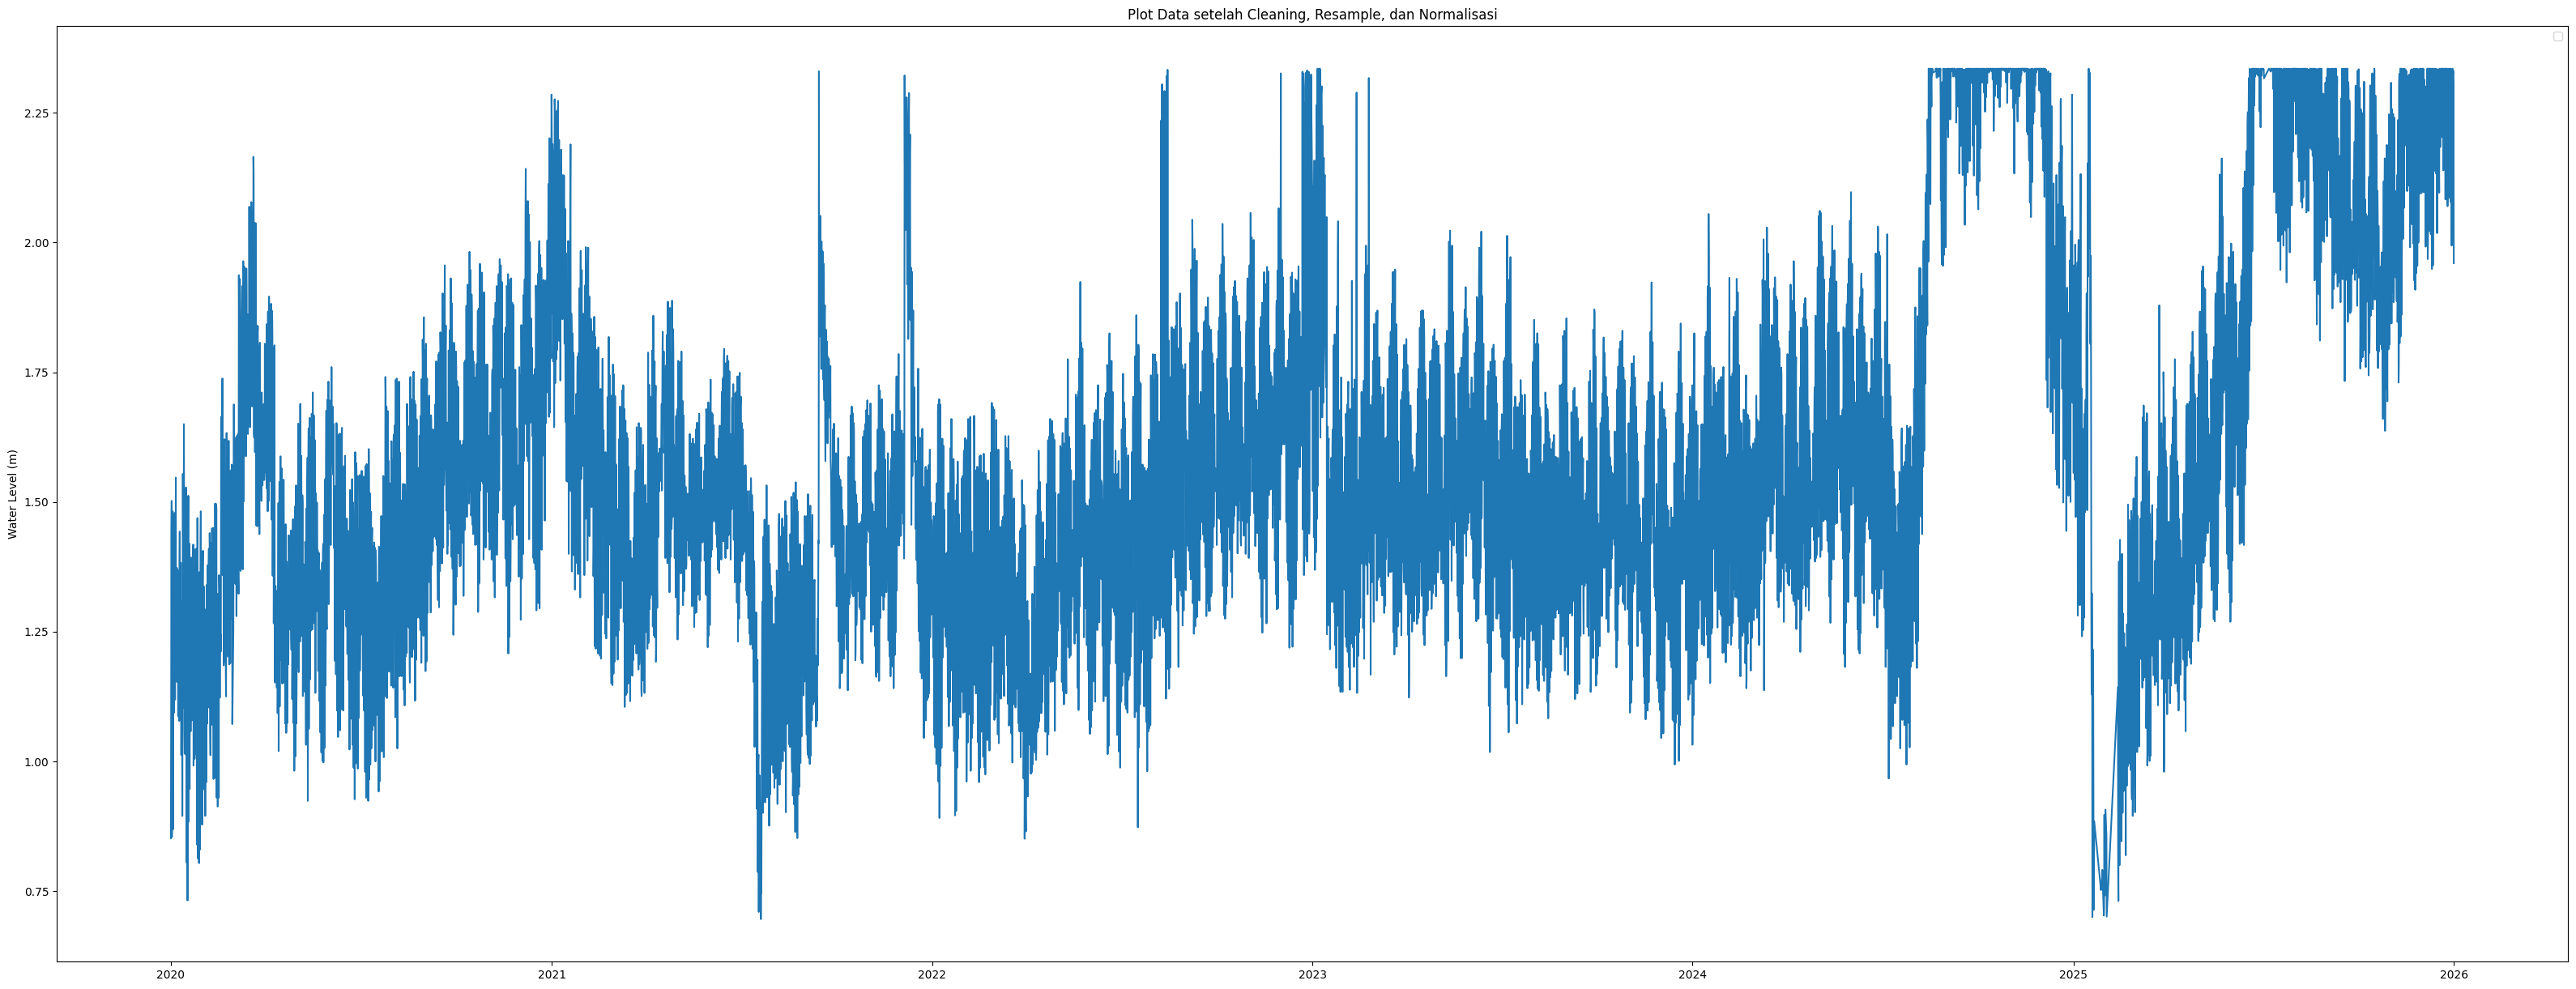

In [81]:
display(df.head()) 
display(df.iloc[4000:4005]) 
display(df.tail())

plt.figure(figsize=(40,15))
plt.plot(df['prs(m)'])
plt.title("Plot Data setelah Cleaning, Resample, dan Normalisasi")
plt.ylabel("Water Level (m)")
plt.legend()
plt.show()

In [82]:
df.describe()

,prs(m)
count,8769.000000
mean,1.599089
std,0.356532
min,0.696000
25%,1.353000
50%,1.544000
75%,1.792000
max,2.335000


Jumlah Data Training  : 7015
Jumlah Data Testing   : 1754
Jumlah Sequence Training  : 6967
Jumlah Sequence Testing   : 1706


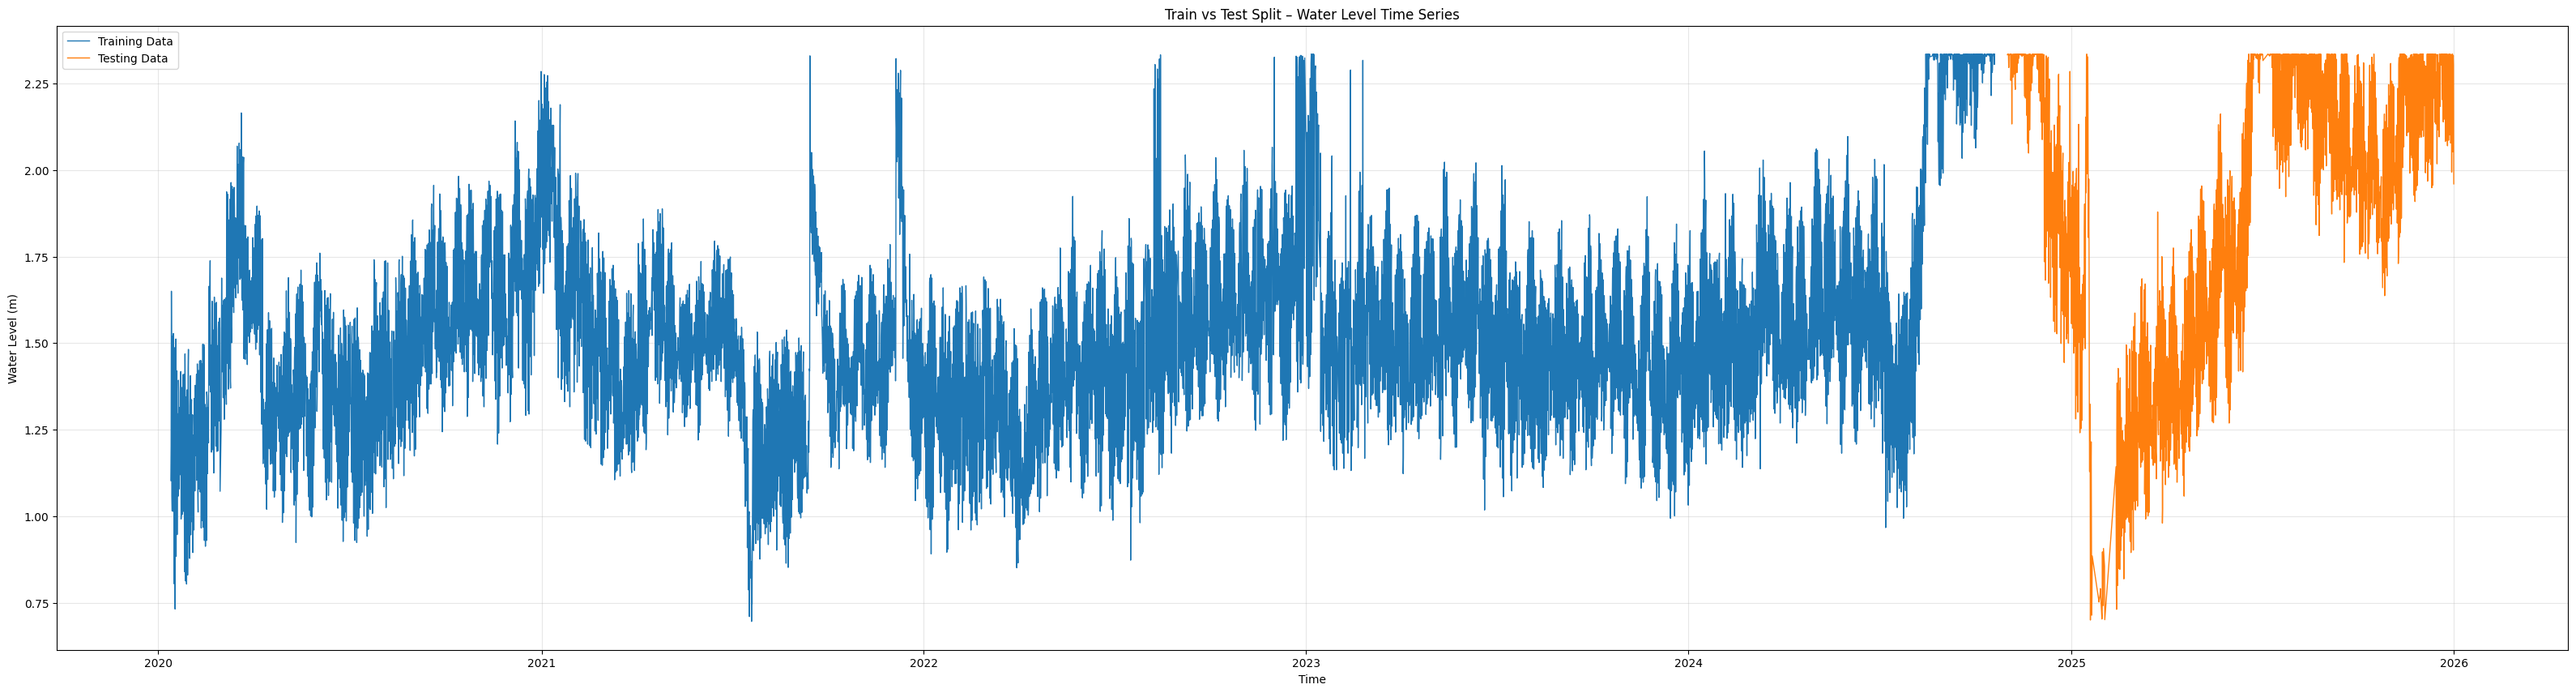

In [83]:
WINDOW_SIZE = 48

data_raw = df[['prs(m)']].values

split_idx = int(0.8 * len(data_raw))
train_data = data_raw[:split_idx]
test_data = data_raw[split_idx:]
print("Jumlah Data Training  :", len(train_data))
print("Jumlah Data Testing   :", len(test_data))

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test, y_test = create_sequences(test_scaled, WINDOW_SIZE)

X_train = X_train.reshape(-1, WINDOW_SIZE, 1)
X_test  = X_test.reshape(-1, WINDOW_SIZE, 1)

print("Jumlah Sequence Training  :", len(X_train))
print("Jumlah Sequence Testing   :", len(X_test))

time_index = df.index
train_time = time_index[WINDOW_SIZE : split_idx]
test_time  = time_index[split_idx + WINDOW_SIZE :]

y_train_plot = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_test_plot  = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

plt.figure(figsize=(40,10))
plt.plot(train_time, y_train_plot, label="Training Data", linewidth=1)
plt.plot(test_time, y_test_plot, label="Testing Data", linewidth=1)
plt.title("Train vs Test Split – Water Level Time Series")
plt.xlabel("Time")
plt.ylabel("Water Level (m)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [86]:
train_stat = pd.DataFrame({
    'prs(m)': train_data.ravel() 
}).describe()

test_stat = pd.DataFrame({
    'prs(m)': test_data.ravel()
}).describe()

perbandingan = pd.DataFrame({
    'Train': train_stat['prs(m)'],
    'Test': test_stat['prs(m)']
}).round(3)

print("Perbandingan TRAIN vs TEST")
display(perbandingan)

Perbandingan TRAIN vs TEST


,Train,Test
count,7015.000,1754.000
mean,1.530,1.876
std,0.287,0.459
min,0.696,0.700
25%,1.340,1.553
50%,1.502,1.998
75%,1.683,2.322
max,2.335,2.335


In [87]:
train_df = pd.DataFrame({
    'Time': time_index[:split_idx],
    'Original (prs(m))': train_data.flatten(),
    'Normalized': train_scaled.flatten()
})

print("Data Train:")
display(train_df.head())
display(train_df.tail())

test_df = pd.DataFrame({
    'Time': time_index[split_idx:],
    'Original (prs(m))': test_data.flatten(),
    'Normalized': test_scaled.flatten()
})

print("Data Test:")
display(test_df.head())
display(test_df.tail())

Data Train:


,Time,Original (prs(m)),Normalized
0,2020-01-01 00:00:00,0.852,0.095180
1,2020-01-01 06:00:00,1.095,0.243441
2,2020-01-01 12:00:00,1.440,0.453935
3,2020-01-01 18:00:00,1.502,0.491763
4,2020-01-02 00:00:00,0.854,0.096400


,Time,Original (prs(m)),Normalized
7010,2024-10-18 12:00:00,2.33500,1.000000
7011,2024-10-18 18:00:00,2.32975,0.996797
7012,2024-10-19 00:00:00,2.33400,0.999390
7013,2024-10-19 06:00:00,2.30500,0.981696
7014,2024-10-19 12:00:00,2.33500,1.000000


Data Test:


,Time,Original (prs(m)),Normalized
0,2024-10-19 18:00:00,2.330581,0.997304
1,2024-10-20 00:00:00,2.335000,1.000000
2,2024-10-20 06:00:00,2.279000,0.965833
3,2024-10-20 12:00:00,2.335000,1.000000
4,2024-10-20 18:00:00,2.332000,0.998170


,Time,Original (prs(m)),Normalized
1749,2025-12-31 00:00:00,2.053,0.827944
1750,2025-12-31 06:00:00,2.321,0.991458
1751,2025-12-31 12:00:00,2.331,0.997559
1752,2025-12-31 18:00:00,2.304,0.981086
1753,2026-01-01 00:00:00,1.960,0.771202


In [88]:
from datetime import datetime

log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    write_graph=True,
    write_images=False,
    update_freq='epoch'
)

model = Sequential([
    Input(shape=(WINDOW_SIZE, 1)),

    LSTM(128, return_sequences=True),
    Dropout(0.1),

    LSTM(64, return_sequences=False),
    Dropout(0.1),

    Dense(32, activation='tanh'),
    Dense(1)
])

optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='mae'
)

model.summary()

callbacks = [
    EarlyStopping(patience=20, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=10, min_lr=1e-5),
    tensorboard_callback
]

history = model.fit(
    X_train, y_train,
    epochs=200,              
    batch_size=32,          
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 48, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 43s 146ms/step - loss: 0.1084 - val_loss: 0.0900 - learning_rate: 5.0000e-04
Epoch 2/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 23s 105ms/step - loss: 0.1018 - val_loss: 0.0843 - learning_rate: 5.0000e-04
Epoch 3/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - loss: 0.0994 - val_loss: 0.0839 - learning_rate: 5.0000e-04
Epoch 4/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 24s 112ms/step - loss: 0.0979 - val_loss: 0.0788 - learning_rate: 5.0000e-04
Epoch 5/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 41s 111ms/step - loss: 0.0941 - val_loss: 0.0740 - learning_rate: 5.0000e-04
Epoch 6/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 24s 109ms/step - loss: 0.0759 - val_loss: 0.0822 - learning_rate: 5.0000e-04
Epoch 7/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 25s 117ms/step - loss: 0.0636 - val_loss: 0.0608 - learning_rate: 5.0000e-04
Epoch 8/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 26s 118ms/step - loss: 0.0611 - val_loss: 0.0578 - learning_rate: 5.0000e-04
Epoch 9/200
218/218 ━━━━━━━━━━━━━━━━━━━━ 25s 115ms/step 

In [89]:
# 8) prediksi
y_pred_scaled = model.predict(X_test)

# 9) Denormalisasi
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred_actual = scaler.inverse_transform(y_pred_scaled).flatten()


54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step


In [90]:
# 10) Evaluasi
mse  = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, y_pred_actual)
mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)
numerator = np.sum((y_test_actual - y_pred_actual) ** 2)
denominator = np.sum((y_test_actual - np.mean(y_test_actual)) ** 2)
nse = 1 - (numerator / denominator)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.4f} ({mape * 100:.2f}%)")
print(f"R²   : {r2:.4f}")
print(f"NSE  : {nse:.4f}")

MSE  : 0.0061
RMSE : 0.0783
MAE  : 0.0530
MAPE : 0.0327 (3.27%)
R²   : 0.9710
NSE  : 0.9710


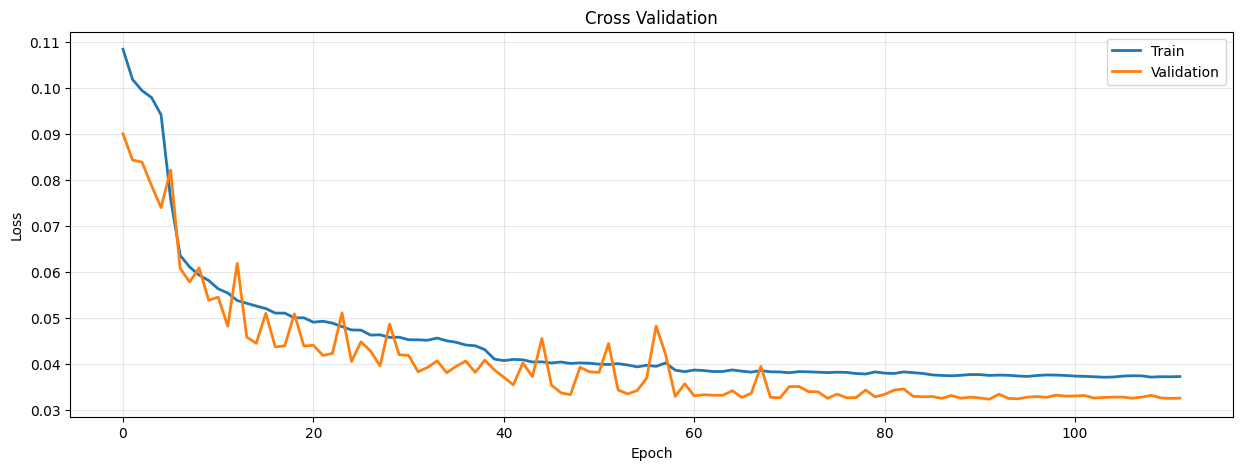

In [91]:
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'], label='Train', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation', linewidth=2)

plt.title('Cross Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

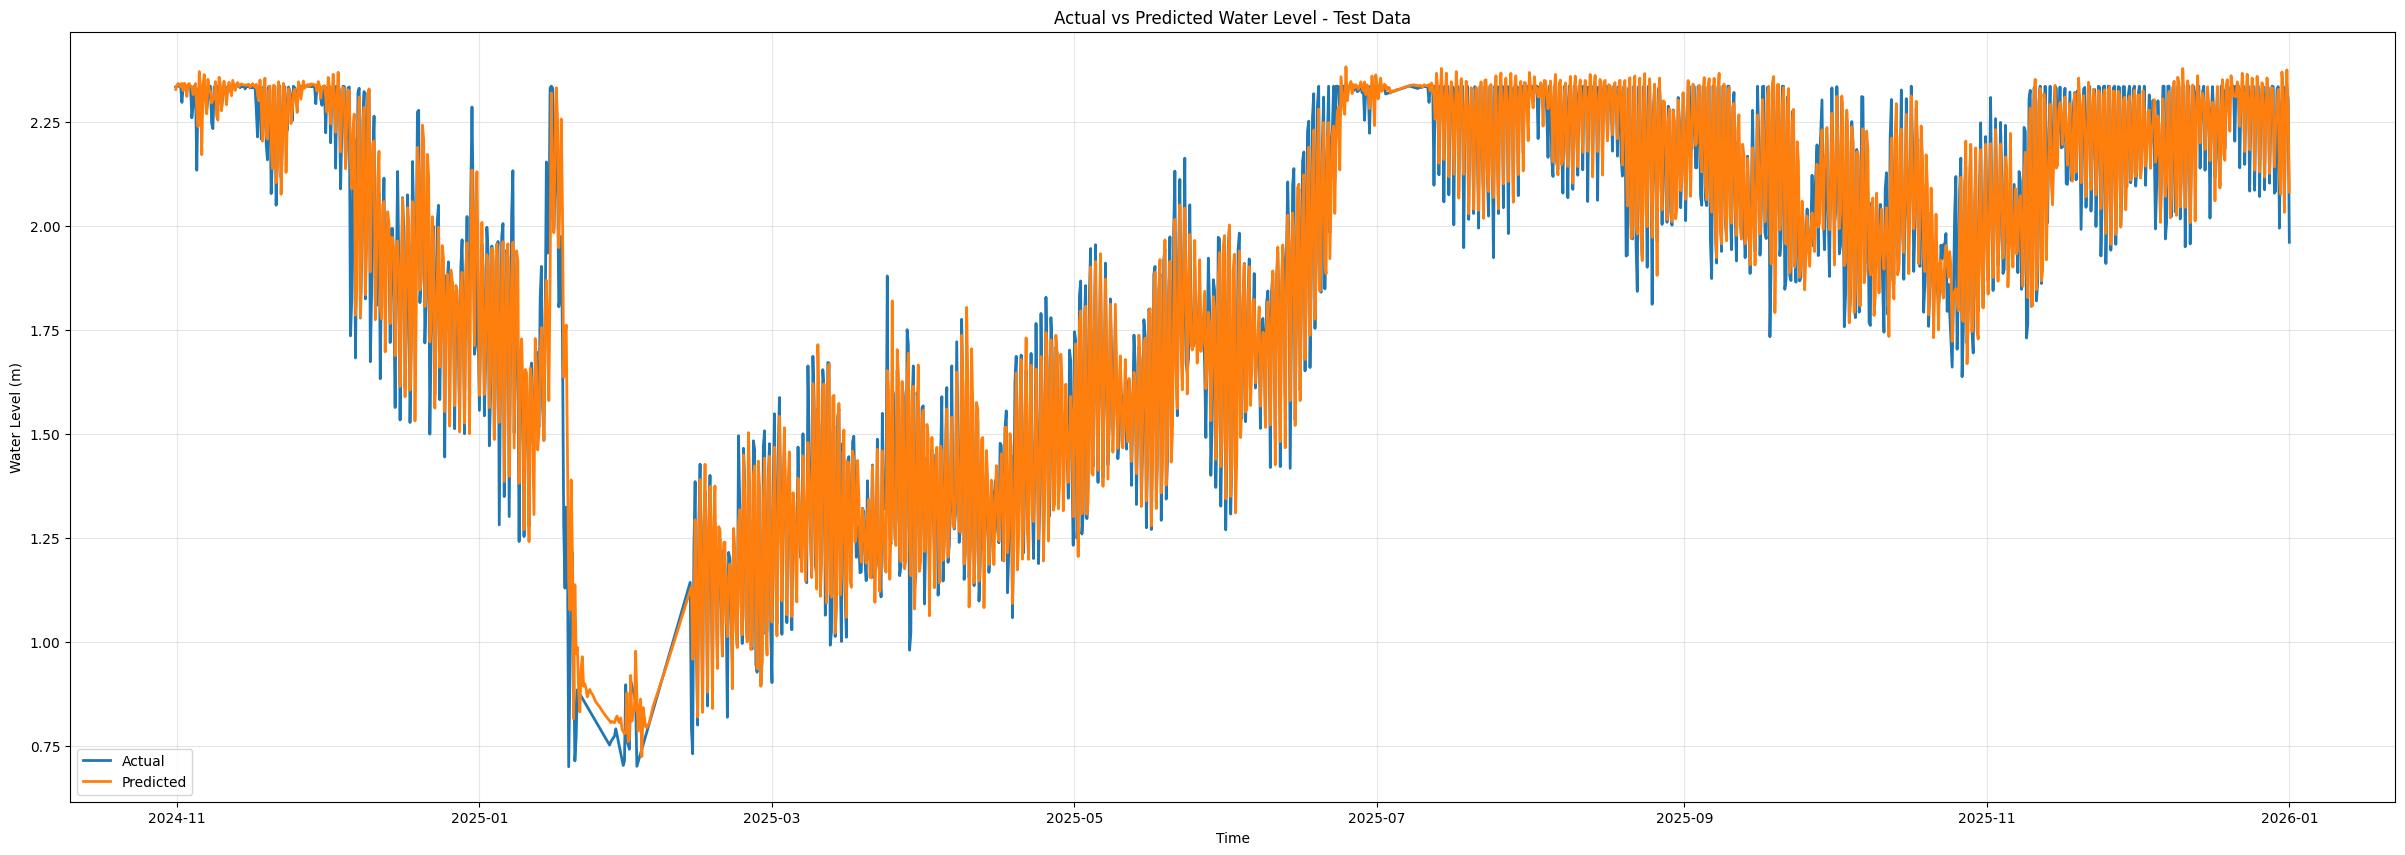

In [101]:
plt.figure(figsize=(30,10))
plt.plot(test_time, y_test_actual, label='Actual', linewidth=2)
plt.plot(test_time, y_pred_actual, label='Predicted', linewidth=2)
plt.title('Actual vs Predicted Water Level - Test Data')
plt.xlabel('Time')
plt.ylabel('Water Level (m)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [93]:
# Display predictions in normalized scale + denormalized scale
pred_df = pd.DataFrame({
    'Time': test_time,
    'Actual (Normalized)': y_test.flatten(),
    'Predicted (Normalized)': y_pred_scaled.flatten()
})

pred_df['Actual'] = scaler.inverse_transform(
    pred_df[['Actual (Normalized)']]
)
pred_df['Predicted (Denormalized)'] = scaler.inverse_transform(
    pred_df[['Predicted (Normalized)']]
)

display(pred_df.head())
display(pred_df.tail())

,Time,Actual (Normalized),Predicted (Normalized),Actual,Predicted (Denormalized)
0,2024-10-31 18:00:00,0.99878,0.995127,2.333,2.327013
1,2024-11-01 00:00:00,1.00000,1.001305,2.335,2.337139
2,2024-11-01 06:00:00,1.00000,1.003990,2.335,2.341539
3,2024-11-01 12:00:00,1.00000,1.002479,2.335,2.339062
4,2024-11-01 18:00:00,1.00000,0.999299,2.335,2.333852


,Time,Actual (Normalized),Predicted (Normalized),Actual,Predicted (Denormalized)
1701,2025-12-31 00:00:00,0.827944,0.815183,2.053,2.032084
1702,2025-12-31 06:00:00,0.991458,0.939946,2.321,2.236571
1703,2025-12-31 12:00:00,0.997559,1.023968,2.331,2.374284
1704,2025-12-31 18:00:00,0.981086,0.965681,2.304,2.278751
1705,2026-01-01 00:00:00,0.771202,0.844859,1.960,2.080723


In [94]:
percentile_95 = np.percentile(df['prs(m)'], 95)
print(f"Persentil ke-95 dari 'prs(m)': {percentile_95}")

Persentil ke-95 dari 'prs(m)': 2.333


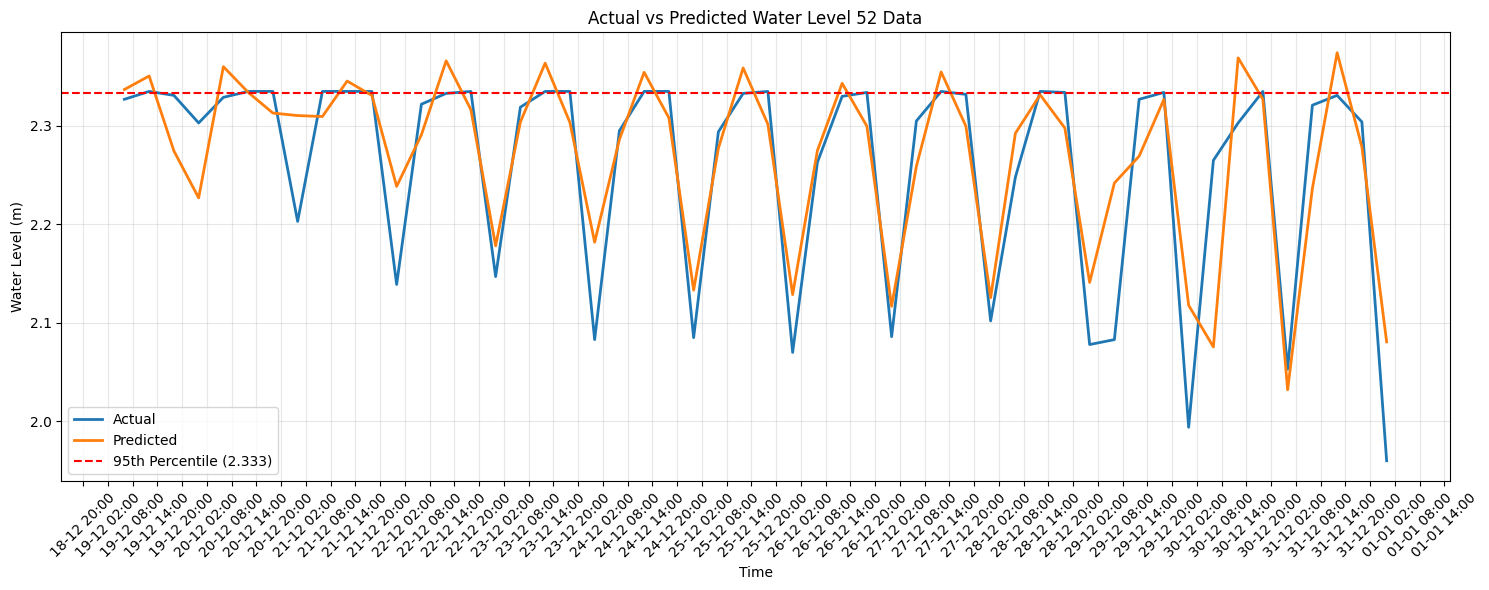

In [95]:
plt.figure(figsize=(15, 6))

plt.plot(test_time[-52:], y_test_actual[-52:], label='Actual', linewidth=2)
plt.plot(test_time[-52:], y_pred_actual[-52:], label='Predicted', linewidth=2)

plt.axhline(y=percentile_95, color='red', linestyle='--',
            label=f'95th Percentile ({percentile_95:.3f})')

plt.title('Actual vs Predicted Water Level 52 Data')
plt.xlabel('Time')
plt.ylabel('Water Level (m)')

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))

plt.xticks(rotation=45)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [96]:
# ── Folder simpan model ────────────────────────────────────────────────────
SAVE_DIR = "model_trial3"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Simpan model Keras ─────────────────────────────────────────────────────
MODEL_PATH   = os.path.join(SAVE_DIR, "lstm_trial3.keras")
model.save(MODEL_PATH)
print(f"✅ Model disimpan  → {MODEL_PATH}")

# ── Simpan scaler ──────────────────────────────────────────────────────────
SCALER_PATH  = os.path.join(SAVE_DIR, "scaler_trial3.pkl")
with open(SCALER_PATH, "wb") as f:
    pickle.dump(scaler, f)
print(f"✅ Scaler disimpan → {SCALER_PATH}")

# ── Simpan threshold (persentil 95) ───────────────────────────────────────
THRESH_PATH  = os.path.join(SAVE_DIR, "threshold_trial3.txt")
with open(THRESH_PATH, "w") as f:
    f.write(str(percentile_95))
print(f"✅ Threshold disimpan → {THRESH_PATH}  (nilai: {percentile_95:.4f} m)")


✅ Model disimpan  → model_trial3\lstm_trial3.keras
✅ Scaler disimpan → model_trial3\scaler_trial3.pkl
✅ Threshold disimpan → model_trial3\threshold_trial3.txt  (nilai: 2.3330 m)
